Initial dataset:
  Business  Sales  Employees      Type    Risk Insurance
0        A     50          5    Retail  Medium       Yes
1        B     55          6      Food    High        No
2        C     52          5    Retail     Low       Yes
3        D    100         15  Services    High        No
4        E     48          4      Food  Medium       Yes


Final encoded dataset ready for distance calculations:
   Sales  Employees  Risk_Ordinal  Insurance_Binary  Type_Food  Type_Retail  \
0     50          5             2                 1        0.0          1.0   
1     55          6             3                 0        1.0          0.0   
2     52          5             1                 1        0.0          1.0   
3    100         15             3                 0        0.0          0.0   
4     48          4             2                 1        1.0          0.0   

   Type_Services  
0            0.0  
1            0.0  
2            0.0  
3            1.0  
4            0

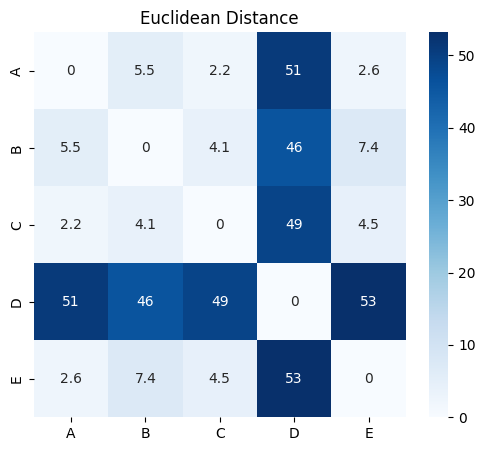

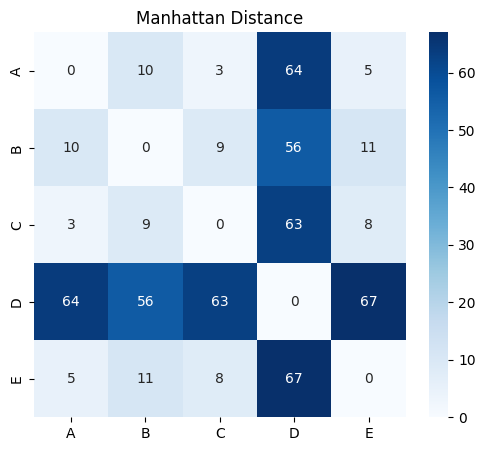

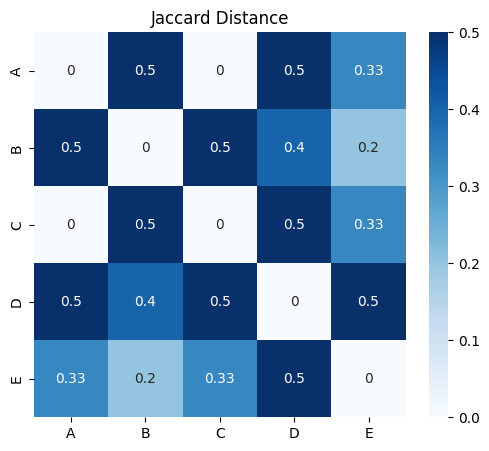

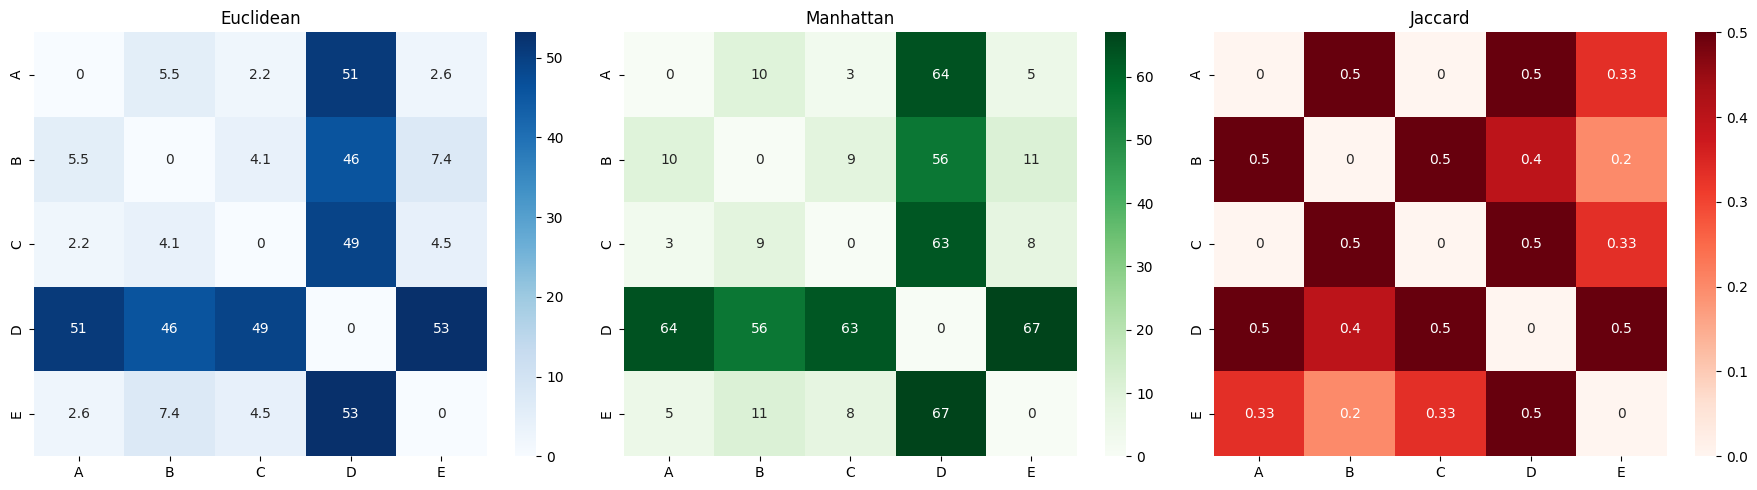

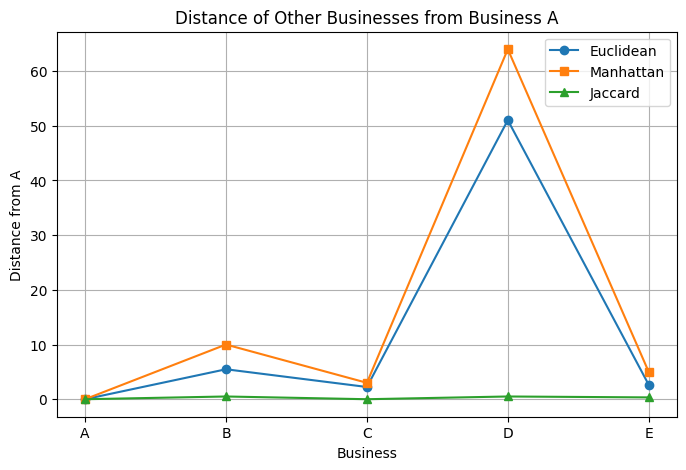

In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# STEP 1: Create the dataset
# ==============================
# Columns:
# - Sales, Employees → numeric
# - Type → nominal categorical
# - Risk → ordinal categorical
# - Insurance → binary

df = pd.DataFrame({
    "Business": ["A","B","C","D","E"],
    "Sales": [50,55,52,100,48],
    "Employees": [5,6,5,15,4],
    "Type": ["Retail","Food","Retail","Services","Food"],
    "Risk": ["Medium","High","Low","High","Medium"],
    "Insurance": ["Yes","No","Yes","No","Yes"]
})

print("Initial dataset:")
print(df)
print("\n")

# ==============================
# STEP 2: Encode categorical variables
# ==============================

# 2a. One-hot encode 'Type' (nominal)
# Why? Euclidean distance cannot handle text categories directly
ohe = OneHotEncoder(sparse_output=False)
type_encoded = ohe.fit_transform(df[["Type"]])
type_df = pd.DataFrame(type_encoded, columns=ohe.get_feature_names_out(["Type"]))

# 2b. Encode 'Risk' (ordinal)
# Map Low=1, Medium=2, High=3 to preserve order
risk_map = {"Low":1, "Medium":2, "High":3}
df["Risk_Ordinal"] = df["Risk"].map(risk_map)

# 2c. Encode 'Insurance' (binary)
# Yes=1, No=0
ins_map = {"Yes":1, "No":0}
df["Insurance_Binary"] = df["Insurance"].map(ins_map)

# 2d. Combine numeric, ordinal, binary, and one-hot categorical features
df_num = df[["Sales","Employees","Risk_Ordinal","Insurance_Binary"]].reset_index(drop=True)
df_final = pd.concat([df_num, type_df], axis=1)

print("Final encoded dataset ready for distance calculations:")
print(df_final)
print("\n")

# ==============================
# STEP 3: Compute distance matrices
# ==============================

# 3a. Euclidean distance (straight-line distance)
dist_euclidean = squareform(pdist(df_final, metric='euclidean'))

# 3b. Manhattan distance (sum of absolute differences)
dist_manhattan = squareform(pdist(df_final, metric='cityblock'))

# 3c. Jaccard distance (binary similarity)
# Convert all values to boolean (True/False) for Jaccard
binary_cols = df_final.astype(bool)
dist_jaccard = squareform(pdist(binary_cols, metric='jaccard'))

# ==============================
# STEP 4: Visualize distance matrices using heatmaps
# ==============================

# Function to plot single heatmap
def plot_distance_matrix(matrix, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(matrix, annot=True, cmap='Blues', xticklabels=df['Business'], yticklabels=df['Business'])
    plt.title(title)
    plt.show()

# Plot individual heatmaps
plot_distance_matrix(dist_euclidean, "Euclidean Distance")
plot_distance_matrix(dist_manhattan, "Manhattan Distance")
plot_distance_matrix(dist_jaccard, "Jaccard Distance")

# Plot all three heatmaps side by side
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.heatmap(dist_euclidean, annot=True, cmap='Blues', xticklabels=df['Business'], yticklabels=df['Business'], ax=axes[0])
axes[0].set_title('Euclidean')
sns.heatmap(dist_manhattan, annot=True, cmap='Greens', xticklabels=df['Business'], yticklabels=df['Business'], ax=axes[1])
axes[1].set_title('Manhattan')
sns.heatmap(dist_jaccard, annot=True, cmap='Reds', xticklabels=df['Business'], yticklabels=df['Business'], ax=axes[2])
axes[2].set_title('Jaccard')
plt.tight_layout()
plt.show()

# ==============================
# STEP 5: Distance of other businesses from Business A
# ==============================
# Reference: Business A (index 0)
ref_idx = 0
euclid_from_A = dist_euclidean[ref_idx]
manhattan_from_A = dist_manhattan[ref_idx]
jaccard_from_A = dist_jaccard[ref_idx]

business_names = df['Business']

plt.figure(figsize=(8,5))
plt.plot(business_names, euclid_from_A, marker='o', label='Euclidean')
plt.plot(business_names, manhattan_from_A, marker='s', label='Manhattan')
plt.plot(business_names, jaccard_from_A, marker='^', label='Jaccard')
plt.xlabel("Business")
plt.ylabel("Distance from A")
plt.title("Distance of Other Businesses from Business A")
plt.legend()
plt.grid(True)
plt.show()


Initial dataset:
  Business  Sales  Employees      Type    Risk Insurance
0        A     50          5    Retail  Medium       Yes
1        B     55          6      Food    High        No
2        C     52          5    Retail     Low       Yes
3        D    100         15  Services    High        No
4        E     48          4      Food  Medium       Yes
5        F     67          9      Food     Low       Yes


Final encoded dataset ready for distance calculations:
   Sales  Employees  Risk_Ordinal  Insurance_Binary  Type_Food  Type_Retail  \
0     50          5             2                 1        0.0          1.0   
1     55          6             3                 0        1.0          0.0   
2     52          5             1                 1        0.0          1.0   
3    100         15             3                 0        0.0          0.0   
4     48          4             2                 1        1.0          0.0   
5     67          9             1                 1  

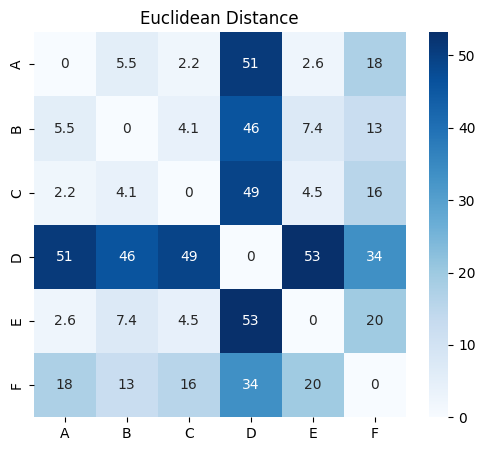

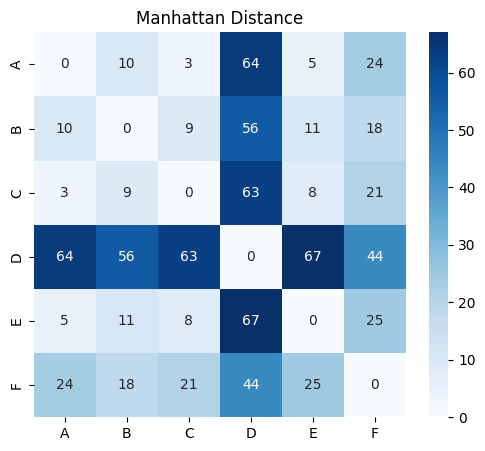

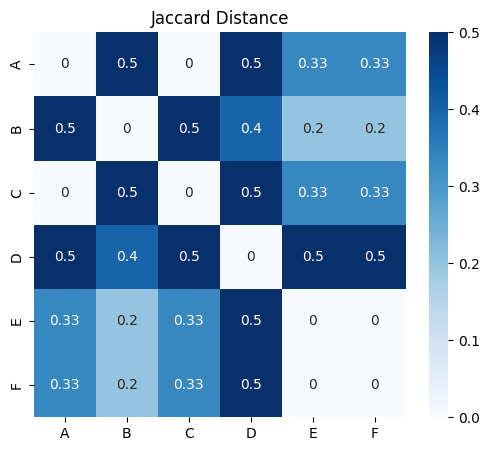

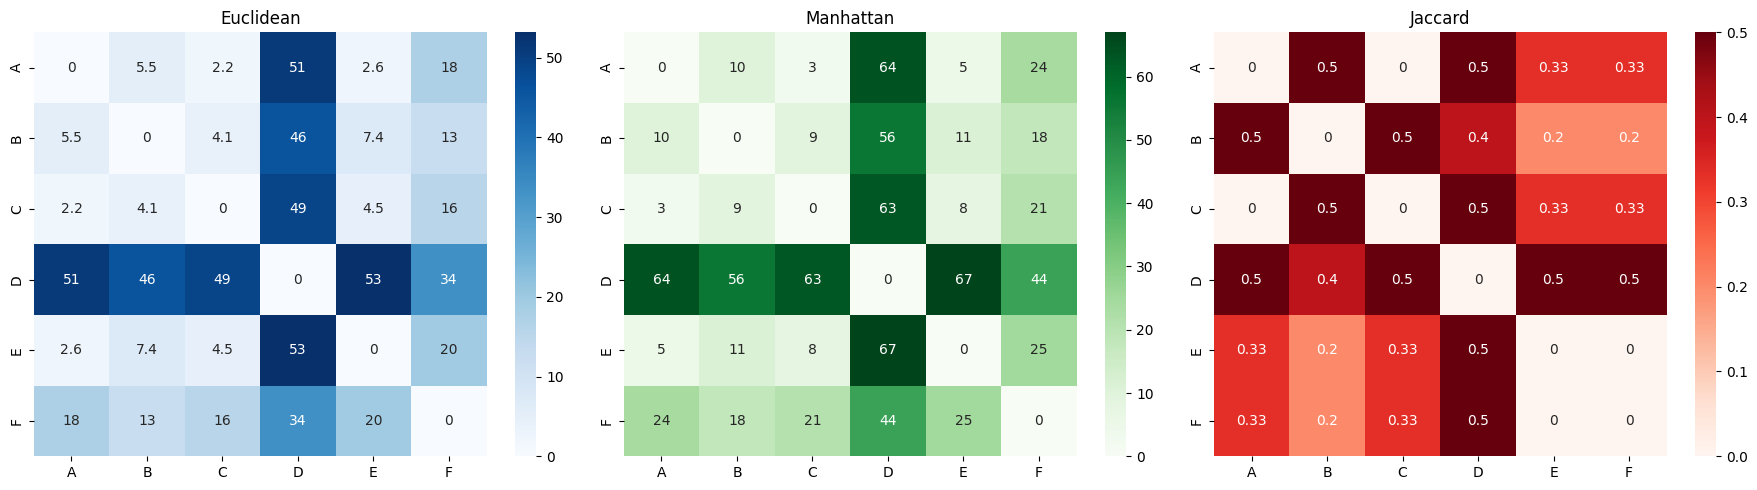

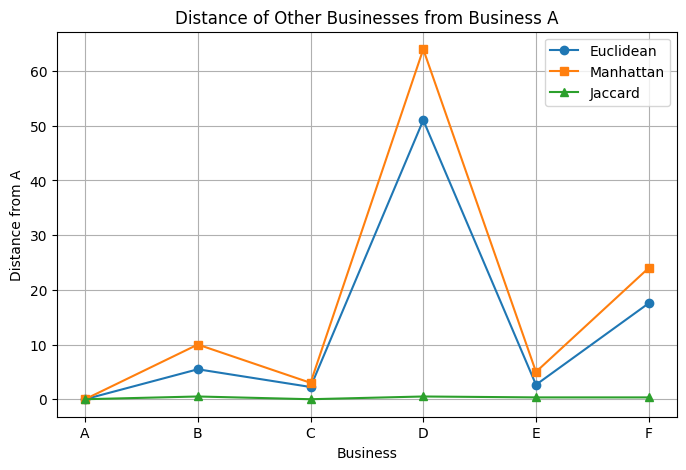

In [3]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# STEP 1: Create the dataset
# ==============================
# Columns:
# - Sales, Employees → numeric
# - Type → nominal categorical
# - Risk → ordinal categorical
# - Insurance → binary

df = pd.DataFrame({
    "Business": ["A","B","C","D","E", "F"],
    "Sales": [50,55,52,100,48, 67],
    "Employees": [5,6,5,15,4, 9],
    "Type": ["Retail","Food","Retail","Services","Food", "Food"],
    "Risk": ["Medium","High","Low","High","Medium", "Low"],
    "Insurance": ["Yes","No","Yes","No","Yes", "Yes"]
})

print("Initial dataset:")
print(df)
print("\n")

# ==============================
# STEP 2: Encode categorical variables
# ==============================

# 2a. One-hot encode 'Type' (nominal)
# Why? Euclidean distance cannot handle text categories directly
ohe = OneHotEncoder(sparse_output=False)
type_encoded = ohe.fit_transform(df[["Type"]])
type_df = pd.DataFrame(type_encoded, columns=ohe.get_feature_names_out(["Type"]))

# 2b. Encode 'Risk' (ordinal)
# Map Low=1, Medium=2, High=3 to preserve order
risk_map = {"Low":1, "Medium":2, "High":3}
df["Risk_Ordinal"] = df["Risk"].map(risk_map)

# 2c. Encode 'Insurance' (binary)
# Yes=1, No=0
ins_map = {"Yes":1, "No":0}
df["Insurance_Binary"] = df["Insurance"].map(ins_map)

# 2d. Combine numeric, ordinal, binary, and one-hot categorical features
df_num = df[["Sales","Employees","Risk_Ordinal","Insurance_Binary"]].reset_index(drop=True)
df_final = pd.concat([df_num, type_df], axis=1)

print("Final encoded dataset ready for distance calculations:")
print(df_final)
print("\n")

# ==============================
# STEP 3: Compute distance matrices
# ==============================

# 3a. Euclidean distance (straight-line distance)
dist_euclidean = squareform(pdist(df_final, metric='euclidean'))

# 3b. Manhattan distance (sum of absolute differences)
dist_manhattan = squareform(pdist(df_final, metric='cityblock'))

# 3c. Jaccard distance (binary similarity)
# Convert all values to boolean (True/False) for Jaccard
binary_cols = df_final.astype(bool)
dist_jaccard = squareform(pdist(binary_cols, metric='jaccard'))

# ==============================
# STEP 4: Visualize distance matrices using heatmaps
# ==============================

# Function to plot single heatmap
def plot_distance_matrix(matrix, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(matrix, annot=True, cmap='Blues', xticklabels=df['Business'], yticklabels=df['Business'])
    plt.title(title)
    plt.show()

# Plot individual heatmaps
plot_distance_matrix(dist_euclidean, "Euclidean Distance")
plot_distance_matrix(dist_manhattan, "Manhattan Distance")
plot_distance_matrix(dist_jaccard, "Jaccard Distance")

# Plot all three heatmaps side by side
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.heatmap(dist_euclidean, annot=True, cmap='Blues', xticklabels=df['Business'], yticklabels=df['Business'], ax=axes[0])
axes[0].set_title('Euclidean')
sns.heatmap(dist_manhattan, annot=True, cmap='Greens', xticklabels=df['Business'], yticklabels=df['Business'], ax=axes[1])
axes[1].set_title('Manhattan')
sns.heatmap(dist_jaccard, annot=True, cmap='Reds', xticklabels=df['Business'], yticklabels=df['Business'], ax=axes[2])
axes[2].set_title('Jaccard')
plt.tight_layout()
plt.show()

# ==============================
# STEP 5: Distance of other businesses from Business A
# ==============================
# Reference: Business A (index 0)
ref_idx = 0
euclid_from_A = dist_euclidean[ref_idx]
manhattan_from_A = dist_manhattan[ref_idx]
jaccard_from_A = dist_jaccard[ref_idx]

business_names = df['Business']

plt.figure(figsize=(8,5))
plt.plot(business_names, euclid_from_A, marker='o', label='Euclidean')
plt.plot(business_names, manhattan_from_A, marker='s', label='Manhattan')
plt.plot(business_names, jaccard_from_A, marker='^', label='Jaccard')
plt.xlabel("Business")
plt.ylabel("Distance from A")
plt.title("Distance of Other Businesses from Business A")
plt.legend()
plt.grid(True)
plt.show()


Initial dataset:
  Business  Sales  Employees      Type    Risk Insurance
0        A     50          5    Retail  Medium       Yes
1        B     55          6      Food    High        No
2        C     52          5    Retail     Low       Yes
3        D    100         15  Services    High        No
4        E     48          4      Food  Medium       Yes
5        F     67          9      Food     Low       Yes


Final encoded dataset ready for distance calculations:
   Sales  Employees  Risk_Ordinal  Insurance_Binary  Type_Food  Type_Retail  \
0     50          5             2                 1        0.0          1.0   
1     55          6             3                 0        1.0          0.0   
2     52          5             1                 1        0.0          1.0   
3    100         15             3                 0        0.0          0.0   
4     48          4             2                 1        1.0          0.0   
5     67          9             1                 1  

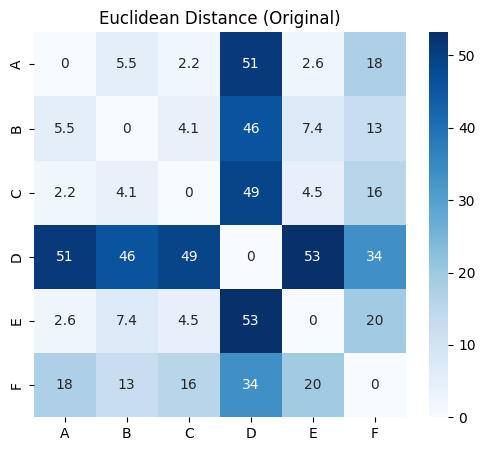

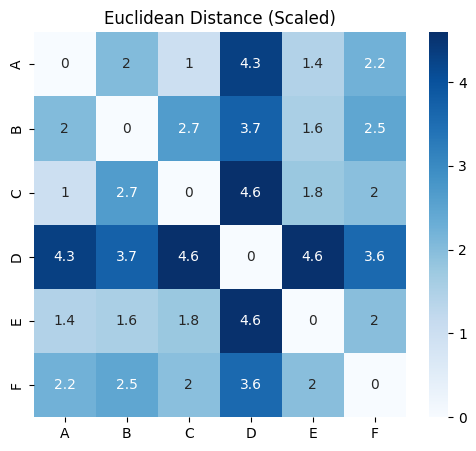

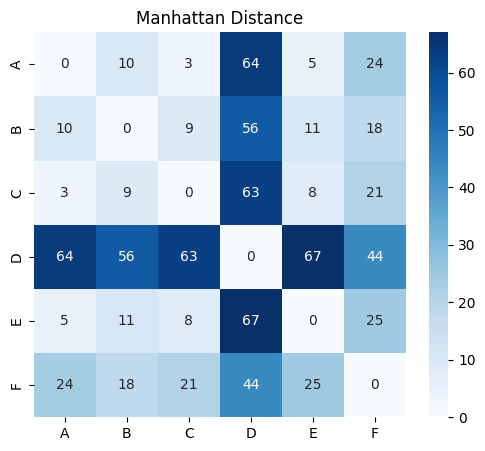

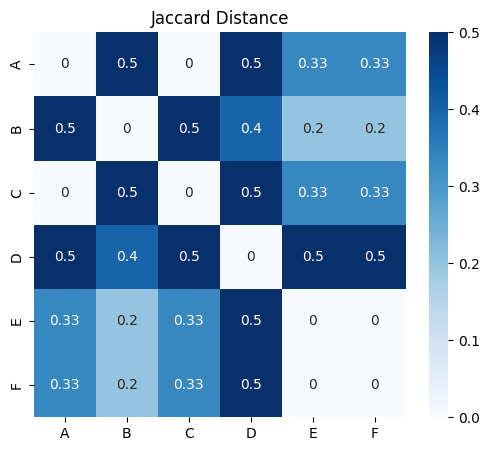

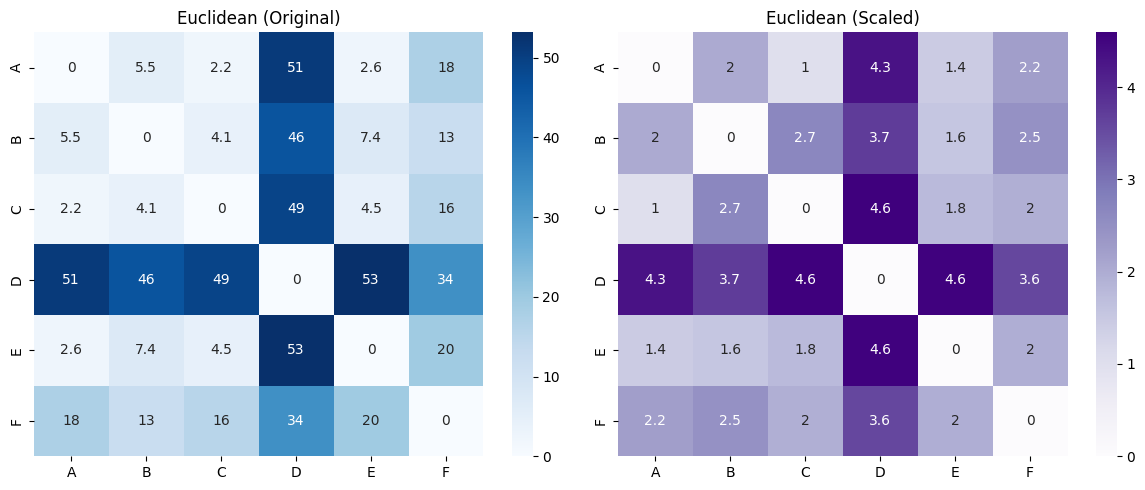

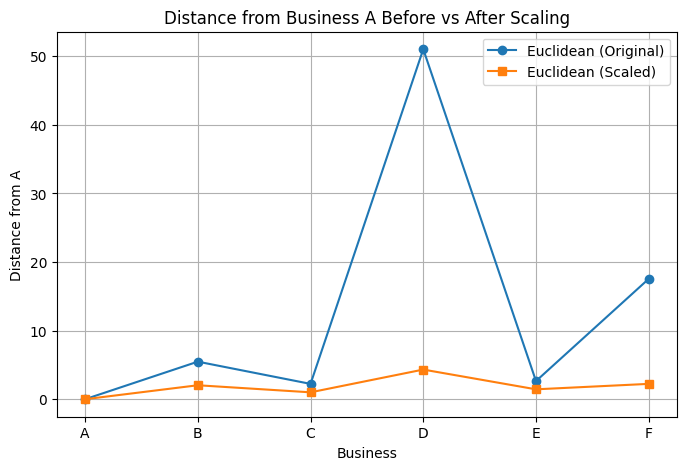

Ranking BEFORE scaling:
  Business  Original_Distance  Scaled_Distance
0        A           0.000000         0.000000
2        C           2.236068         1.006110
4        E           2.645751         1.443111
1        B           5.477226         2.036399
5        F          17.549929         2.238436
3        D          51.029403         4.323439

Ranking AFTER scaling:
  Business  Original_Distance  Scaled_Distance
0        A           0.000000         0.000000
2        C           2.236068         1.006110
4        E           2.645751         1.443111
1        B           5.477226         2.036399
5        F          17.549929         2.238436
3        D          51.029403         4.323439


In [4]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# STEP 1: Create the dataset
# ==============================
# Columns:
# - Sales, Employees → numeric
# - Type → nominal categorical
# - Risk → ordinal categorical
# - Insurance → binary

df = pd.DataFrame({
    "Business": ["A","B","C","D","E", "F"],
    "Sales": [50,55,52,100,48, 67],
    "Employees": [5,6,5,15,4, 9],
    "Type": ["Retail","Food","Retail","Services","Food", "Food"],
    "Risk": ["Medium","High","Low","High","Medium", "Low"],
    "Insurance": ["Yes","No","Yes","No","Yes", "Yes"]
})

print("Initial dataset:")
print(df)
print("\n")

# ==============================
# STEP 2: Encode categorical variables
# ==============================

# 2a. One-hot encode 'Type' (nominal)
ohe = OneHotEncoder(sparse_output=False)
type_encoded = ohe.fit_transform(df[["Type"]])
type_df = pd.DataFrame(type_encoded, columns=ohe.get_feature_names_out(["Type"]))

# 2b. Encode 'Risk' (ordinal)
risk_map = {"Low":1, "Medium":2, "High":3}
df["Risk_Ordinal"] = df["Risk"].map(risk_map)

# 2c. Encode 'Insurance' (binary)
ins_map = {"Yes":1, "No":0}
df["Insurance_Binary"] = df["Insurance"].map(ins_map)

# 2d. Combine numeric, ordinal, binary, and one-hot categorical features
df_num = df[["Sales","Employees","Risk_Ordinal","Insurance_Binary"]].reset_index(drop=True)
df_final = pd.concat([df_num, type_df], axis=1)

print("Final encoded dataset ready for distance calculations:")
print(df_final)
print("\n")

# ==============================
# STEP 3: Scale numeric features using StandardScaler
# ==============================

scaler = StandardScaler()

df_scaled = df_final.copy()
df_scaled[["Sales","Employees"]] = scaler.fit_transform(df_scaled[["Sales","Employees"]])

print("Dataset after scaling numeric features:")
print(df_scaled)
print("\n")

# ==============================
# STEP 4: Compute distance matrices
# ==============================

# Euclidean distance (original)
dist_euclidean = squareform(pdist(df_final, metric='euclidean'))

# Euclidean distance (scaled)
dist_euclidean_scaled = squareform(pdist(df_scaled, metric='euclidean'))

# Manhattan distance
dist_manhattan = squareform(pdist(df_final, metric='cityblock'))

# Jaccard distance
binary_cols = df_final.astype(bool)
dist_jaccard = squareform(pdist(binary_cols, metric='jaccard'))

# ==============================
# STEP 5: Visualize distance matrices
# ==============================

def plot_distance_matrix(matrix, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(matrix, annot=True, cmap='Blues',
                xticklabels=df['Business'],
                yticklabels=df['Business'])
    plt.title(title)
    plt.show()

plot_distance_matrix(dist_euclidean, "Euclidean Distance (Original)")
plot_distance_matrix(dist_euclidean_scaled, "Euclidean Distance (Scaled)")
plot_distance_matrix(dist_manhattan, "Manhattan Distance")
plot_distance_matrix(dist_jaccard, "Jaccard Distance")

# ==============================
# STEP 6: Side-by-side comparison
# ==============================

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(dist_euclidean, annot=True, cmap='Blues',
            xticklabels=df['Business'], yticklabels=df['Business'], ax=axes[0])
axes[0].set_title('Euclidean (Original)')

sns.heatmap(dist_euclidean_scaled, annot=True, cmap='Purples',
            xticklabels=df['Business'], yticklabels=df['Business'], ax=axes[1])
axes[1].set_title('Euclidean (Scaled)')

plt.tight_layout()
plt.show()

# ==============================
# STEP 7: Distance from Business A
# ==============================

ref_idx = 0

euclid_from_A = dist_euclidean[ref_idx]
euclid_scaled_from_A = dist_euclidean_scaled[ref_idx]

business_names = df['Business']

plt.figure(figsize=(8,5))

plt.plot(business_names, euclid_from_A, marker='o', label='Euclidean (Original)')
plt.plot(business_names, euclid_scaled_from_A, marker='s', label='Euclidean (Scaled)')

plt.xlabel("Business")
plt.ylabel("Distance from A")
plt.title("Distance from Business A Before vs After Scaling")
plt.legend()
plt.grid(True)

plt.show()

# ==============================
# STEP 8: Compare rankings
# ==============================

comparison = pd.DataFrame({
    "Business": business_names,
    "Original_Distance": euclid_from_A,
    "Scaled_Distance": euclid_scaled_from_A
})

print("Ranking BEFORE scaling:")
print(comparison.sort_values("Original_Distance"))

print("\nRanking AFTER scaling:")
print(comparison.sort_values("Scaled_Distance"))